# Scalable Customer Segmentation and Retail Analytics 

## Subject : Programming For Big Data
## Student : Andrew Hegarty


## Project Overview
This project performs customer segmentation on retail transaction data using **RFM (Recency, Frequency, Monetary) analysis**. The aim is to better understand customer purchasing behaviour and group customers into meaningful segments.

## Approach
- Clean and preprocess raw transaction data
- Construct RFM features for each customer  
- Apply data transformation and scaling  
- Use **K-Means clustering** to identify customer segments  

## Analysis & Visualisation
In addition to clustering, exploratory data analysis was carried out to better understand the dataset and the resulting segments. This includes:

- Revenue by Country
- Monthly Revenue Trend
- Top Selling Products
- Customer Behaviour Analysis
- Hourly Sales 
- Distribution and comparison of RFM features  
- Cluster-level analysis using bar charts (e.g., number of customers, average recency, frequency, and monetary value)  
- Log-scaled plots to better interpret skewed data  

These visualisations help interpret the characteristics of each customer segment and highlight key differences between groups.

## Objective
Perform analysis on existing data and also to identify distinct customer groups (via machine learning) such as high-value, regular, and at-risk customers, which can support targeted marketing strategies and business decision-making.

In [0]:
# Get the retail_data from the volume

df_raw = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv("/Volumes/workspace/default/retail_data/")
)

display(df_raw.limit(20))   # Show the data

Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,01/12/2009 7:45,6.95,13085,United Kingdom
489434,79323P,PINK CHERRY LIGHTS,12,01/12/2009 7:45,6.75,13085,United Kingdom
489434,79323W,WHITE CHERRY LIGHTS,12,01/12/2009 7:45,6.75,13085,United Kingdom
489434,22041,"""RECORD FRAME 7"""" SINGLE SIZE """,48,01/12/2009 7:45,2.1,13085,United Kingdom
489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,01/12/2009 7:45,1.25,13085,United Kingdom
489434,22064,PINK DOUGHNUT TRINKET POT,24,01/12/2009 7:45,1.65,13085,United Kingdom
489434,21871,SAVE THE PLANET MUG,24,01/12/2009 7:45,1.25,13085,United Kingdom
489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,01/12/2009 7:45,5.95,13085,United Kingdom
489435,22350,CAT BOWL,12,01/12/2009 7:46,2.55,13085,United Kingdom
489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,01/12/2009 7:46,3.75,13085,United Kingdom


In [0]:
df_raw = df_raw.withColumnRenamed("Customer ID", "CustomerID")   # Rename column to allow for sql processing later
df_raw.columns

['Invoice',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'Price',
 'CustomerID',
 'Country']

In [0]:
df_raw.printSchema()   # Display schema to make decision on data cleansing

root
 |-- Invoice: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: string (nullable = true)
 |-- Price: double (nullable = true)
 |-- CustomerID: integer (nullable = true)
 |-- Country: string (nullable = true)



In [0]:
from pyspark.sql import functions as F

df_raw = df_raw.withColumn(   
    "InvoiceDate",                          # Convert InvoiceDate to timestamp
    F.to_timestamp("InvoiceDate", "dd/MM/yyyy H:mm")
)

df_raw.printSchema()                        # Reshow schema

root
 |-- Invoice: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- Price: double (nullable = true)
 |-- CustomerID: integer (nullable = true)
 |-- Country: string (nullable = true)



In [0]:
df_raw.select("InvoiceDate").show(10, truncate=False) # Show sample of InvoiceDate

+-------------------+
|InvoiceDate        |
+-------------------+
|2009-12-01 07:45:00|
|2009-12-01 07:45:00|
|2009-12-01 07:45:00|
|2009-12-01 07:45:00|
|2009-12-01 07:45:00|
|2009-12-01 07:45:00|
|2009-12-01 07:45:00|
|2009-12-01 07:45:00|
|2009-12-01 07:46:00|
|2009-12-01 07:46:00|
+-------------------+
only showing top 10 rows


In [0]:
print("Total rows:", df_raw.count())

print("Rows with NULL CustomerID:",
      df_raw.filter(F.col("CustomerID").isNull()).count())

print("Cancelled invoices (Invoice starts with C):",
      df_raw.filter(F.col("Invoice").startswith("C")).count())

print("Quantity <= 0:",
      df_raw.filter(F.col("Quantity") <= 0).count())

print("Price <= 0:",
      df_raw.filter(F.col("Price") <= 0).count())

Total rows: 1067371
Rows with NULL CustomerID: 243007
Cancelled invoices (Invoice starts with C): 19494
Quantity <= 0: 22950
Price <= 0: 6207


In [0]:
df = (
    df_raw
    .filter(F.col("CustomerID").isNotNull())
    .filter(~F.col("Invoice").startswith("C"))
    .filter(F.col("Quantity") > 0)
    .filter(F.col("Price") > 0)
)

print("Cleaned rows:", df.count())  # Display the number of rows in the cleaned DataFrame

Cleaned rows: 805549


In [0]:
# Create new column revenue from qty x price
df = df.withColumn(
    "Revenue",
    F.round(F.col("Quantity") * F.col("Price"), 2)
)

df.select("Quantity","Price","Revenue").show(10)    # Show the new column

+--------+-----+-------+
|Quantity|Price|Revenue|
+--------+-----+-------+
|      12| 6.95|   83.4|
|      12| 6.75|   81.0|
|      12| 6.75|   81.0|
|      48|  2.1|  100.8|
|      24| 1.25|   30.0|
|      24| 1.65|   39.6|
|      24| 1.25|   30.0|
|      10| 5.95|   59.5|
|      12| 2.55|   30.6|
|      12| 3.75|   45.0|
+--------+-----+-------+
only showing top 10 rows


In [0]:
revenue_by_country = (
    df.groupBy("Country")                                      # Group by Country
      .agg(
          F.round(F.sum("Revenue"),2).alias("TotalRevenue"),   # Sum Revenue
          F.countDistinct("Invoice").alias("NumOrders"),       # Count Distinct Invoices
          F.countDistinct("CustomerID").alias("NumCustomers")  # Count Distinct Customers
      )
      .orderBy(F.col("TotalRevenue").desc())                   # Order by TotalRevenue
)

display(revenue_by_country.limit(10))

Country,TotalRevenue,NumOrders,NumCustomers
United Kingdom,1.47231475E7,33541,5350
EIRE,621631.11,567,5
Netherlands,554232.34,228,22
Germany,431262.46,789,107
France,355257.47,614,95
Australia,169968.11,95,15
Spain,109178.53,154,41
Switzerland,100365.34,90,22
Sweden,91549.72,104,19
Denmark,69862.19,43,12


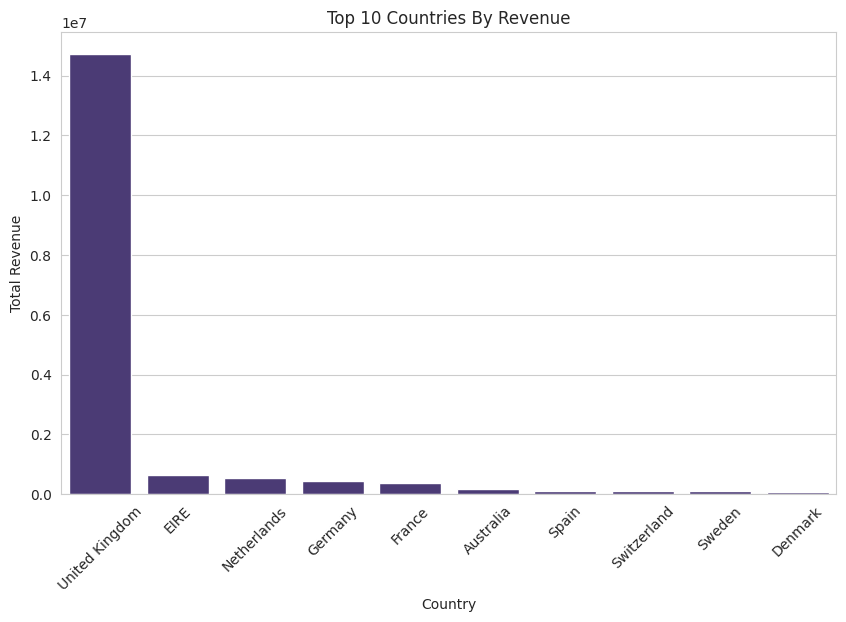

In [0]:
import seaborn as sns
import matplotlib.pyplot as plt

pdf = revenue_by_country.limit(10).toPandas()

sns.set_style("whitegrid")
sns.set_palette("viridis")

plt.figure(figsize=(10,6))

sns.barplot(
    data=pdf,
    x="Country",
    y="TotalRevenue"
)

plt.xticks(rotation=45)
plt.title("Top 10 Countries By Revenue")
plt.xlabel("Country")
plt.ylabel("Total Revenue")

plt.show()

In [0]:
df_time = (                                         # Create new columns Year and Month
    df
    .withColumn("Year", F.year("InvoiceDate"))
    .withColumn("Month", F.month("InvoiceDate"))
)

monthly_revenue = (                                          # group by year month sum revenue and count distinct invoices
    df_time
    .groupBy("Year","Month")
    .agg(
        F.round(F.sum("Revenue"),2).alias("MonthlyRevenue"), # Sum Revenue
        F.countDistinct("Invoice").alias("NumOrders")        # Count Distinct Invoices
    )
    .orderBy("Year","Month")
)

monthly_revenue = monthly_revenue.withColumn(
    "YearMonth",
    F.concat_ws("-", F.col("Year"), F.lpad(F.col("Month"), 2, "0"))  # Create YearMonth column
)

display(monthly_revenue)

Year,Month,MonthlyRevenue,NumOrders,YearMonth
2009,12,686654.16,1512,2009-12
2010,1,557319.06,1011,2010-01
2010,2,506371.06,1104,2010-02
2010,3,699608.99,1524,2010-03
2010,4,594609.19,1329,2010-04
2010,5,599985.79,1377,2010-05
2010,6,639066.58,1497,2010-06
2010,7,591636.74,1381,2010-07
2010,8,604242.65,1293,2010-08
2010,9,831615.0,1689,2010-09


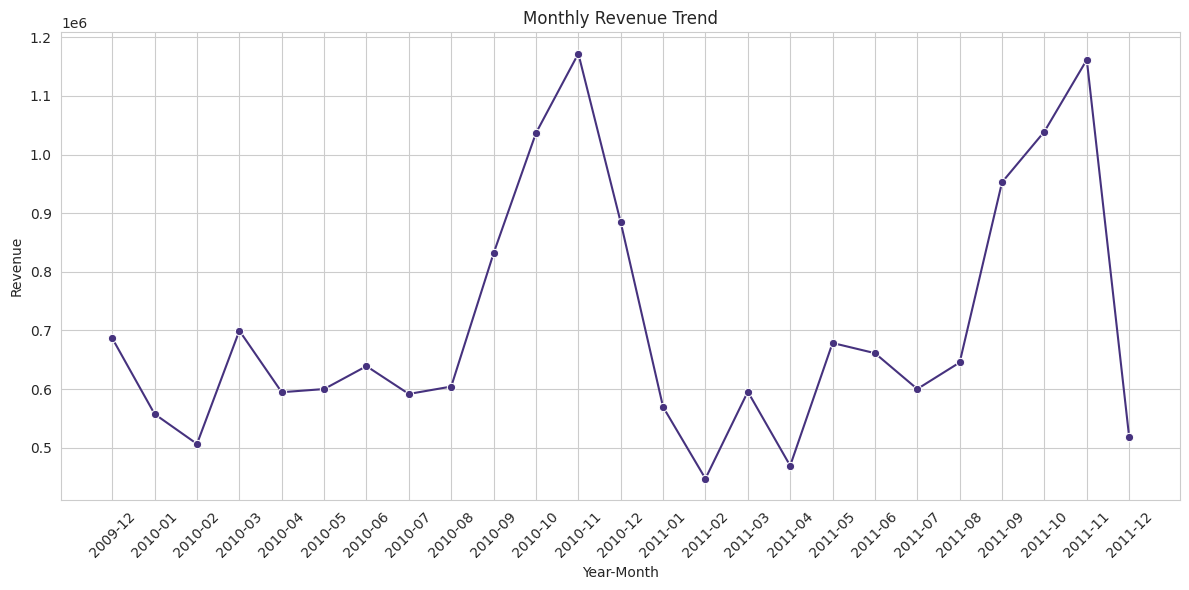

In [0]:
pdf_monthly = monthly_revenue.toPandas()
pdf_monthly = pdf_monthly.sort_values("YearMonth")

sns.set_style("whitegrid")
sns.set_palette("viridis")

plt.figure(figsize=(12,6))

sns.lineplot(
    data=pdf_monthly,    # Pandas DataFrame
    x="YearMonth",       # X-axis
    y="MonthlyRevenue",  # Y-axis
    marker="o"
)

plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.xlabel("Year-Month")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

In [0]:
top_products = (
    df.groupBy("Description")   # Group by Description sum qty and revenue
      .agg(
          F.sum("Quantity").alias("TotalQuantity")
          # F.round(F.sum("Revenue"),2).alias("TotalRevenue")
      )
      .orderBy(F.col("TotalQuantity").desc())
      .limit(10)
)

display(top_products)

Description,TotalQuantity
WORLD WAR 2 GLIDERS ASSTD DESIGNS,109169
WHITE HANGING HEART T-LIGHT HOLDER,93640
"PAPER CRAFT , LITTLE BIRDIE",80995
ASSORTED COLOUR BIRD ORNAMENT,79913
MEDIUM CERAMIC TOP STORAGE JAR,77916
JUMBO BAG RED RETROSPOT,75759
BROCADE RING PURSE,71129
PACK OF 60 PINK PAISLEY CAKE CASES,55270
60 TEATIME FAIRY CAKE CASES,53495
PACK OF 72 RETROSPOT CAKE CASES,46107


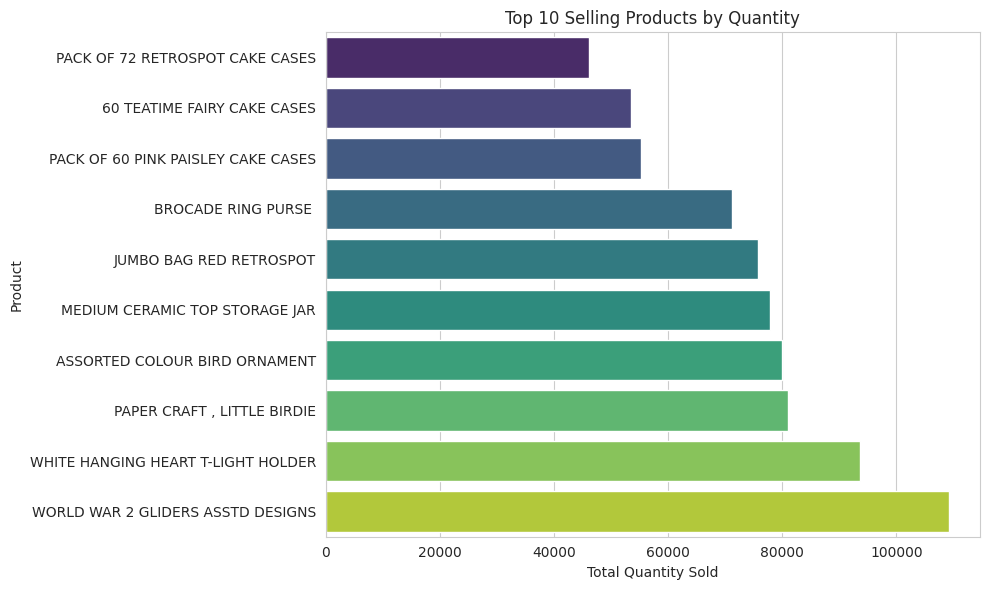

In [0]:
import numpy as np

pdf_products = top_products.toPandas()
pdf_products = pdf_products.sort_values("TotalQuantity", ascending=True)

sns.set_style("whitegrid")

plt.figure(figsize=(10,6))

colors = sns.color_palette("viridis", len(pdf_products))

sns.barplot(
    data=pdf_products, # Pandas DataFrame
    x="TotalQuantity", # X-axis 
    y="Description",   # Y-axis
    hue="Description",
    palette=colors,
    legend=False
)

plt.title("Top 10 Selling Products by Quantity")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [0]:
customer_stats = (
    df.groupBy("CustomerID")    # Group by Customer ID sum revenue count invoices and average transaction value
      .agg(
          F.round(F.sum("Revenue"),2).alias("TotalSpent"),
          F.countDistinct("Invoice").alias("NumOrders"),
          F.round(F.avg("Revenue"),2).alias("AvgTransactionValue")
      )
      .orderBy(F.col("TotalSpent").desc())
)

display(customer_stats.limit(10))

CustomerID,TotalSpent,NumOrders,AvgTransactionValue
18102,608821.65,145,575.45
14646,528602.52,151,137.34
14156,313946.37,156,77.56
14911,295972.63,398,26.32
17450,246973.09,51,582.48
13694,196482.81,143,128.84
17511,175603.55,60,91.89
16446,168472.5,2,56157.5
16684,147142.77,55,204.93
12415,144458.37,28,156.0


Databricks visualization. Run in Databricks to view.

In [0]:
hourly_sales = (      # Group by hour sum revenue count distinct invoices
    df
    .withColumn("Hour", F.hour("InvoiceDate"))
    .groupBy("Hour")
    .agg(
        F.round(F.sum("Revenue"),2).alias("TotalRevenue"),
        F.countDistinct("Invoice").alias("NumOrders")
    )
    .orderBy("Hour")
)

display(hourly_sales)

Hour,TotalRevenue,NumOrders
6,4.25,1
7,76212.57,76
8,528877.66,979
9,1509659.88,2548
10,2360784.82,4364
11,2271810.99,4609
12,2750224.63,6170
13,2401116.92,5418
14,1995849.27,4559
15,1882943.79,3992


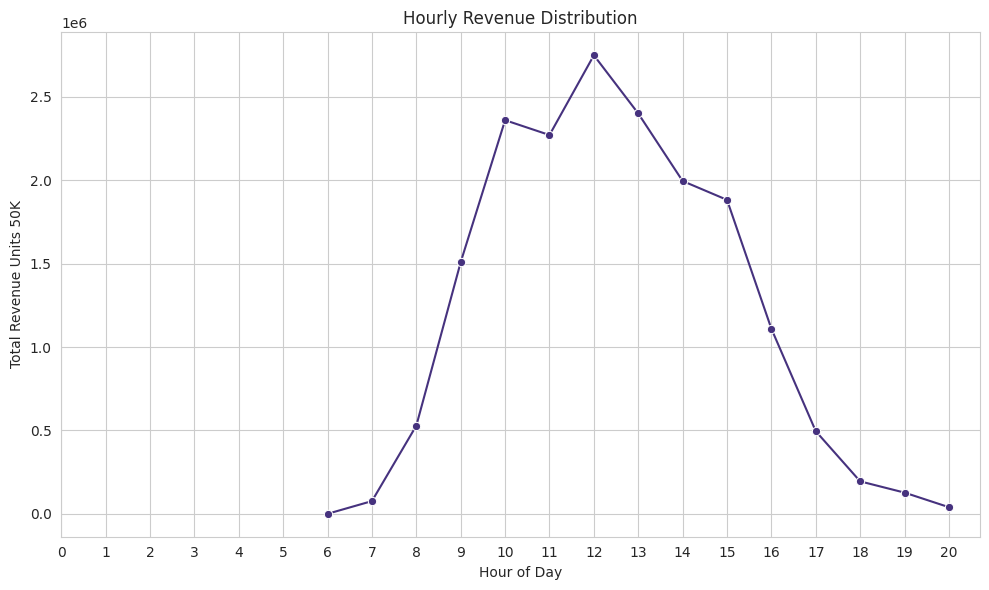

In [0]:
pdf_hourly = hourly_sales.toPandas()
pdf_hourly = pdf_hourly.sort_values("Hour")

sns.set_style("whitegrid")
sns.set_palette("viridis")

plt.figure(figsize=(10,6))

sns.lineplot(
    data=pdf_hourly,  # Pandas DataFrame
    x="Hour",         # X-axis
    y="TotalRevenue", # Y-axis
    marker="o"        # Marker
)

plt.title("Hourly Revenue Distribution")
plt.xlabel("Hour of Day")
plt.ylabel("Total Revenue Units 50K")

plt.xticks(range(0, 21))  # ensures all hours show nicely

plt.tight_layout()
plt.show()

In [0]:
# Get latest date in dataset
snapshot_date = df.agg(F.max("InvoiceDate")).first()[0]

rfm = (
    df.groupBy("CustomerID")                                                       # group by CustomerID
      .agg(
          F.datediff(F.lit(snapshot_date), F.max("InvoiceDate")).alias("Recency"), # days since last purchase
          F.countDistinct("Invoice").alias("Frequency"),                           # number of orders
          F.round(F.sum("Revenue"),2).alias("Monetary")                            # total spend
      )
)

display(rfm.limit(20))

CustomerID,Recency,Frequency,Monetary
13008,323,3,612.13
15321,70,12,6709.73
13408,1,106,51733.46
16199,392,7,942.75
14895,7,38,25119.54
13573,50,6,916.47
15093,18,23,14326.11
14018,645,1,367.15
17682,10,11,4456.78
13820,418,3,660.65


In [0]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=["Recency","Frequency","Monetary"],   # Define the input cols 
    outputCol="features"                            # Define the output col
)

rfm_features = assembler.transform(rfm)             # Transform the features

display(rfm_features.limit(20))

CustomerID,Recency,Frequency,Monetary,features
13008,323,3,612.13,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""323.0"",""3.0"",""612.13""]}"
15321,70,12,6709.73,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""70.0"",""12.0"",""6709.73""]}"
13408,1,106,51733.46,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""1.0"",""106.0"",""51733.46""]}"
16199,392,7,942.75,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""392.0"",""7.0"",""942.75""]}"
14895,7,38,25119.54,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""7.0"",""38.0"",""25119.54""]}"
13573,50,6,916.47,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""50.0"",""6.0"",""916.47""]}"
15093,18,23,14326.11,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""18.0"",""23.0"",""14326.11""]}"
14018,645,1,367.15,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""645.0"",""1.0"",""367.15""]}"
17682,10,11,4456.78,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""10.0"",""11.0"",""4456.78""]}"
13820,418,3,660.65,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""418.0"",""3.0"",""660.65""]}"


In [0]:
from pyspark.ml.clustering import KMeans

kmeans = KMeans(                         # Define 4 clusters and use a seed
    k=4,
    seed=42,
    featuresCol="features"
)

model = kmeans.fit(rfm_features)         # fit the kmeans model

clusters = model.transform(rfm_features) # transform the features

display(clusters.limit(20))                        # display the clusters

CustomerID,Recency,Frequency,Monetary,features,prediction
13008,323,3,612.13,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""323.0"",""3.0"",""612.13""]}",0
15321,70,12,6709.73,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""70.0"",""12.0"",""6709.73""]}",0
13408,1,106,51733.46,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""1.0"",""106.0"",""51733.46""]}",1
16199,392,7,942.75,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""392.0"",""7.0"",""942.75""]}",0
14895,7,38,25119.54,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""7.0"",""38.0"",""25119.54""]}",0
13573,50,6,916.47,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""50.0"",""6.0"",""916.47""]}",0
15093,18,23,14326.11,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""18.0"",""23.0"",""14326.11""]}",0
14018,645,1,367.15,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""645.0"",""1.0"",""367.15""]}",0
17682,10,11,4456.78,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""10.0"",""11.0"",""4456.78""]}",0
13820,418,3,660.65,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""418.0"",""3.0"",""660.65""]}",0


In [0]:
cluster_summary = (
    clusters.groupBy("prediction")                              # Group by prediction
      .agg(
          F.round(F.avg("Recency"), 2).alias("AvgRecency"),     # Average Recency
          F.round(F.avg("Frequency"), 2).alias("AvgFrequency"), # Average Frequency
          F.round(F.avg("Monetary"), 2).alias("AvgMonetary"),   # Average Monetary 
          F.count("*").alias("NumCustomers")                    # Number of Customers 
      )
      .orderBy("prediction")                                    # Order by prediction
)

display(cluster_summary)


prediction,AvgRecency,AvgFrequency,AvgMonetary,NumCustomers
0,202.14,5.63,2138.7,5831
1,51.0,77.95,70200.43,39
2,0.5,148.0,568712.09,2
3,3.83,135.0,232908.49,6


Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

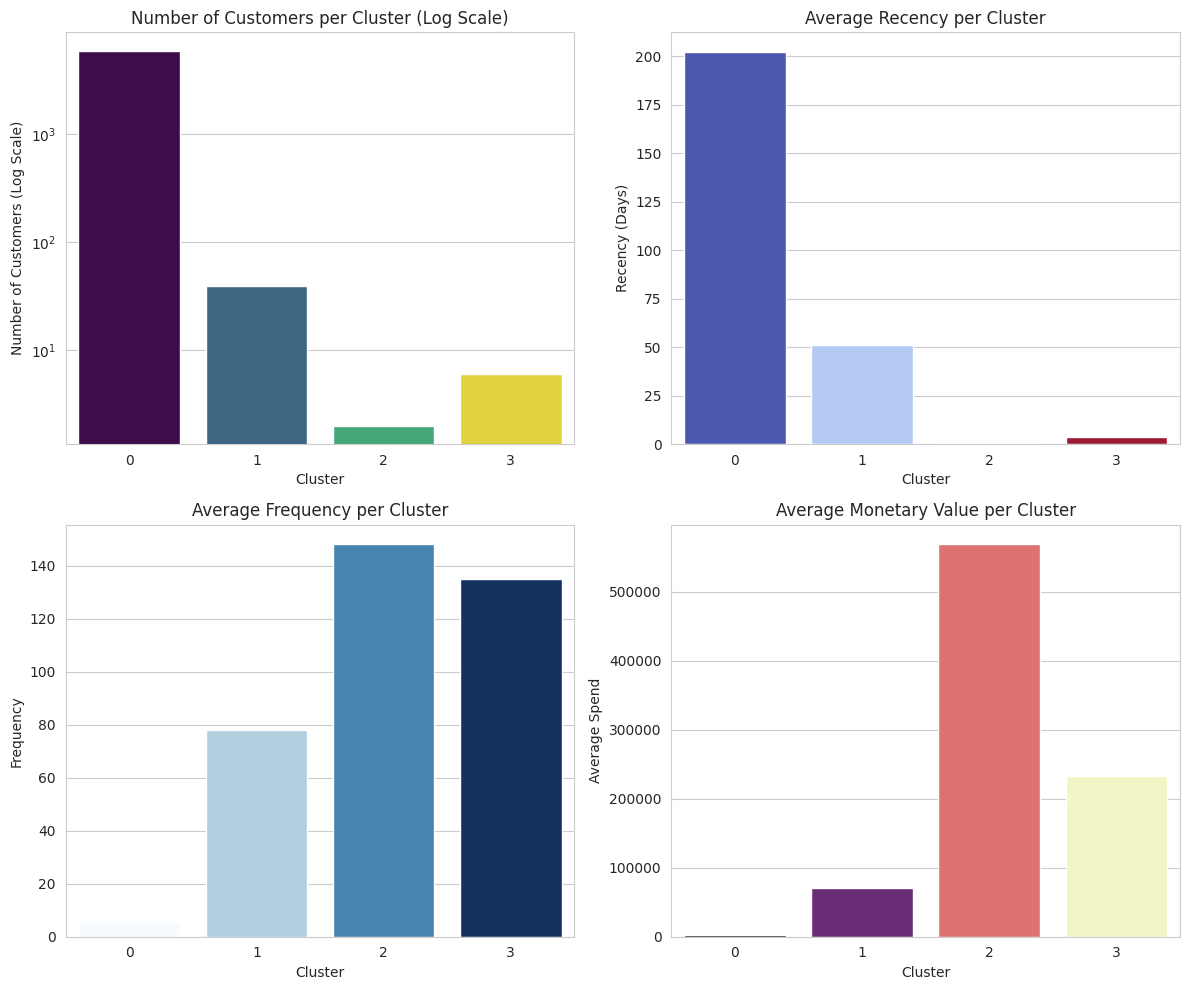

In [0]:
pdf_clusters = cluster_summary.toPandas()

sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(12,10))

################################
# 1. Number of Customers Graph #
################################
sns.barplot(
    data=pdf_clusters,
    x="prediction",
    y="NumCustomers",
    hue="prediction",
    palette="viridis",
    legend=False,
    ax=axes[0,0]
)
axes[0,0].set_yscale("log")
axes[0,0].set_title("Number of Customers per Cluster (Log Scale)")
axes[0,0].set_xlabel("Cluster")
axes[0,0].set_ylabel("Number of Customers (Log Scale)")

####################
# 2. Recency Graph #
####################
sns.barplot(
    data=pdf_clusters,
    x="prediction",
    y="AvgRecency",
    hue="prediction",
    palette="coolwarm",
    legend=False,
    ax=axes[0,1]
)
axes[0,1].set_title("Average Recency per Cluster")
axes[0,1].set_xlabel("Cluster")
axes[0,1].set_ylabel("Recency (Days)")

######################
# 3. Frequency Graph #
######################
sns.barplot(
    data=pdf_clusters,
    x="prediction",
    y="AvgFrequency",
    hue="prediction",
    palette="Blues",
    legend=False,
    ax=axes[1,0]
)
axes[1,0].set_title("Average Frequency per Cluster")
axes[1,0].set_xlabel("Cluster")
axes[1,0].set_ylabel("Frequency")

#####################
# 4. Monetary Graph #
#####################
sns.barplot(
    data=pdf_clusters,
    x="prediction",
    y="AvgMonetary",
    hue="prediction",
    palette="magma",
    legend=False,
    ax=axes[1,1]
)
axes[1,1].set_title("Average Monetary Value per Cluster")
axes[1,1].set_xlabel("Cluster")
axes[1,1].set_ylabel("Average Spend")

# The four graphs are build now show them in a grid

plt.tight_layout()
plt.show()